Импорты загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/oil_sales_synth.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df.head()

,date,sales
0,2022-01-01,120.914151
1,2022-01-02,121.753170
2,2022-01-03,128.465137
3,2022-01-04,125.971193
4,2022-01-05,112.271616


График ряда

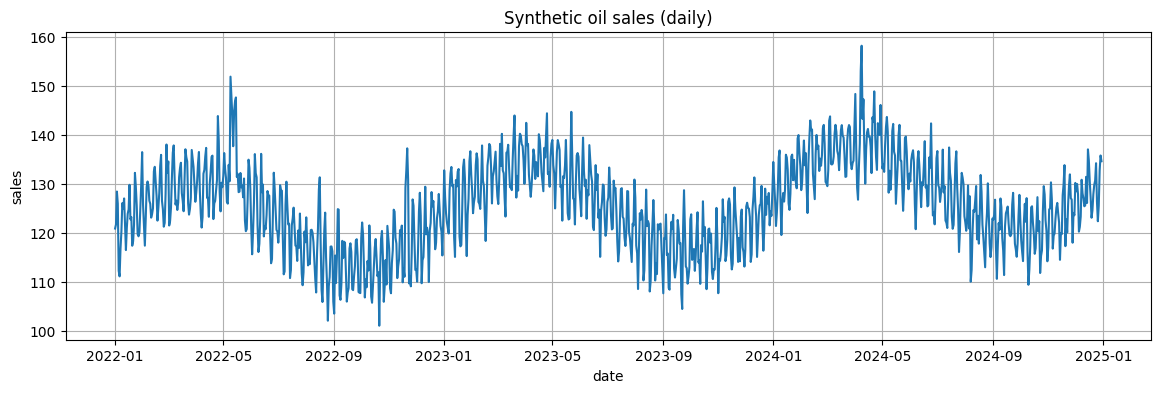

In [2]:
plt.figure(figsize=(14,4))
plt.plot(df["date"], df["sales"])
plt.title("Synthetic oil sales (daily)")
plt.xlabel("date")
plt.ylabel("sales")
plt.grid(True)
plt.show()

In [3]:
df["sales"].describe()

count    1095.000000
mean      125.612312
std         8.880155
min       101.083072
25%       119.580553
50%       125.726194
75%       131.983335
max       158.215553
Name: sales, dtype: float64

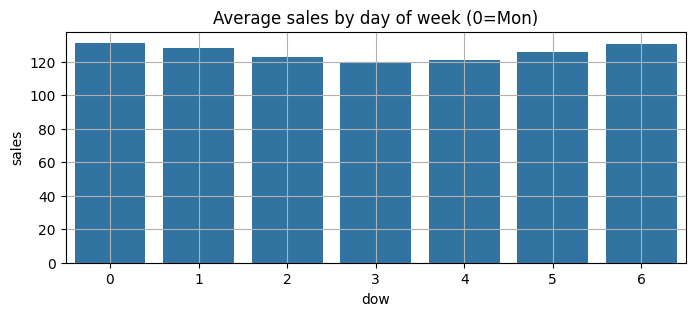

,dow,sales
0,0,131.295266
1,1,128.397074
2,2,122.868006
3,3,119.884824
4,4,120.694543
5,5,125.707325
6,6,130.371600


In [4]:
df["dow"] = df["date"].dt.dayofweek  # 0=Mon
g = df.groupby("dow")["sales"].mean().reset_index()

plt.figure(figsize=(8,3))
sns.barplot(data=g, x="dow", y="sales")
plt.title("Average sales by day of week (0=Mon)")
plt.grid(True)
plt.show()

g

Виден тренд/сезонность/шум
Поэтому baseline seasonal naive на 7 дней логичен
Для модели делаем lag-features